<a href="https://colab.research.google.com/github/iarabertopena/ml-learning-lab/blob/main/stream_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Bibliotecas

In [1]:
%%writefile requirements.txt
numpy
pandas
scipy
matplotlib
seaborn
capymoa

Overwriting requirements.txt


In [2]:
!pip install -r requirements.txt

### Imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from capymoa.classifier import (
HoeffdingAdaptiveTree,
AdaptiveRandomForestClassifier,
SAMkNN,
StreamingGradientBoostedTrees,
StreamingRandomPatches
)

from capymoa.evaluation import (
prequential_evaluation,
ClassificationEvaluator,
ClassificationWindowedEvaluator
)

### Datasets

In [4]:
from capymoa.datasets import Electricity
stream = Electricity()
stream.next_instance().x

electricity.arff: 704kB [00:00, 790kB/s]                    


array([0.      , 1.      , 0.      , 0.056443, 0.439155, 0.003467,
       0.422915, 0.414912])

In [5]:
from capymoa.datasets import Hyper100k
stream = Hyper100k()
stream.next_instance().x

Hyper100k.arff: 8.59MB [00:01, 5.37MB/s]                            


array([0.39717434, 0.34751803, 0.29405703, 0.50648363, 0.11596709,
       0.77053588, 0.65989271, 0.15674689, 0.37820205, 0.13976268])

In [6]:
from capymoa.datasets import RTG_2abrupt
stream = RTG_2abrupt()
stream.next_instance().x

RTG_2abrupt.arff: 25.3MB [00:01, 21.5MB/s]                            


array([0.73087819, 0.41008081, 0.20771484, 0.33271706, 0.96775591,
       0.00611718, 0.9637048 , 0.93986539, 0.94719492, 0.93708215,
       0.39717434, 0.34751803, 0.29405703, 0.50648363, 0.11596709,
       0.77053588, 0.65989271, 0.15674689, 0.37820205, 0.13976268,
       0.69494798, 0.80522777, 0.00502518, 0.52313516, 0.74398449,
       0.1420227 , 0.4817283 , 0.54455481, 0.57710026, 0.20491355])

In [7]:
from capymoa.datasets import CovtypeTiny
stream = CovtypeTiny()
stream.next_instance().x

covtype_n1000.arff: 24.0kB [00:00, 30.5kB/s]                   


array([2.596e+03, 5.100e+01, 3.000e+00, 2.580e+02, 0.000e+00, 5.100e+02,
       2.210e+02, 2.320e+02, 1.480e+02, 6.279e+03, 1.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00])

In [8]:
from capymoa.datasets import Sensor
stream = Sensor()
stream.next_instance().x

sensor.arff: 15.0MB [00:01, 13.9MB/s]                   


array([58.     , 19.7336 , 37.0933 , 71.76   ,  2.69964])

In [9]:
datasets = {
    "Electricity": Electricity,
    "Hyper100k": Hyper100k,
    "RTG_2abrupt": RTG_2abrupt,
    "CovtypeTiny": CovtypeTiny,
    "Sensor": Sensor
}

In [10]:
# visualizando o número de classes:
for dataclass_name, dataclass_class in datasets.items():
    print(f"\n{dataclass_name}")

    stream = dataclass_class()
    _ = stream.next_instance()
    schema = stream.get_schema()

    n_classes = len(schema.get_label_values())
    print("Número de classes:", n_classes)


Electricity
Número de classes: 2

Hyper100k
Número de classes: 2

RTG_2abrupt
Número de classes: 5

CovtypeTiny
Número de classes: 7

Sensor
Número de classes: 57


### Métricas de avaliação

In [11]:
def get_evaluators(schema):

    return {
        "global": ClassificationEvaluator(),
        "window": ClassificationWindowedEvaluator(window_size=1000),
    }

In [12]:
def extract_metrics(results):

    extracted = {}

    for name, ev in results.items():
        metrics = ev.get_metrics()

        extracted[name] = {
            "accuracy": metrics.get("accuracy"),
            "kappa": metrics.get("kappa")
        }

    return extracted

In [13]:
# Accuracy:
# Proporção de instâncias corretamente classificadas.
# Mede o desempenho geral do modelo ao longo do stream (pode ser influenciada por desbalanceamento entre classes).

# Kappa (Cohen’s Kappa):
# Mede o desempenho do modelo em relação ao acaso, considerando a distribuição das classes.
# Mais robusta que a accuracy em cenários desbalanceados.
# Valores:
#   1 → perfeito
#   0 → equivalente ao acaso
#   < 0 → pior que o acaso

# Accuracy (Sliding Window):
# Accuracy calculada apenas nas últimas N instâncias, refletindo o desempenho recente do modelo.
# Útil para detectar concept drift (quanto menor a janela, mais sensível a mudanças rápidas).

# Kappa (Sliding Window):
# Versão do Kappa considerando apenas a janela recente.
# Avalia a qualidade das previsões atuais em relação ao acaso, sendo + informativo que accuracy em streams com drift.

### Definindo os modelos

In [14]:
def get_models(schema):
    return {
        "HAT": HoeffdingAdaptiveTree(schema=schema),
        "ARF": AdaptiveRandomForestClassifier(schema=schema),
        "SAMkNN": SAMkNN(schema=schema),
        "SGBT": StreamingGradientBoostedTrees(schema=schema),
        "SRP": StreamingRandomPatches(schema=schema)
    }

In [15]:
# HAT (Hoeffding Adaptive Tree):
# Árvore de decisão incremental baseada no limite de Hoeffding que aprende a partir de dados em fluxo (sem precisar armazenar tudo).
# Possui mecanismos de adaptação a concept drift, substituindo ramos da árvore quando detecta mudança no comportamento dos dados.

# ARF (Adaptive Random Forest):
# Ensemble de várias Hoeffding Trees, onde cada árvore aprende em subconjuntos diferentes dos dados (bagging online).
# Usa detectores de drift para substituir modelos ruins.

# SAMkNN (Self-Adjusting Memory kNN):
# Versão adaptativa do kNN para data streams, que mantém uma memória de curto e longo prazo.
# Ajusta dinamicamente quais dados usar para prever, lidando bem com concept drift ao esquecer padrões antigos.

# SGBT (Streaming Gradient Boosted Trees):
# Versão online do Gradient Boosting que combina várias árvores sequencialmente corrigindo erros anteriores.
# Aprende de forma incremental em fluxo de dados, podendo capturar relações complexas (mas é mais custoso computacionalmente).

# SRP (Streaming Random Patches):
# Ensemble que combina amostragem de instâncias e atributos, onde cada modelo vê um subconjunto diferente dos dados e features.
# Similar ao Random Forest, mas adaptado para data streams, com bom equilíbrio entre diversidade e desempenho.

### Loop principal

In [16]:
def run_experiment(dataset_name, dataset_class, max_instances=2000):

    dataset_results = {}

    stream = dataset_class()
    _ = stream.next_instance()
    schema = stream.get_schema()

    print(f"\nDataset: {dataset_name}")

    for name, model in get_models(schema).items():
        print(f"\nRodando modelo: {name}")

        stream = dataset_class()

        res = prequential_evaluation(
            stream=stream,
            learner=model,
            max_instances=max_instances
        )

        dataset_results[name] = {
            "accuracy": res["cumulative"].accuracy(),
            "kappa": res["cumulative"].kappa()
        }

        print("Accuracy:", res["cumulative"].accuracy())
        print("Kappa:", res["cumulative"].kappa())

    return dataset_results

In [19]:
results = run_experiment("CovtypeTiny", CovtypeTiny)


Dataset: CovtypeTiny

Rodando modelo: HAT
Accuracy: 62.637362637362635
Kappa: 35.371081038622954

Rodando modelo: ARF
Accuracy: 76.72327672327673
Kappa: 56.649913944039454

Rodando modelo: SAMkNN
Accuracy: 81.31868131868131
Kappa: 66.9180971636307

Rodando modelo: SGBT
Accuracy: 74.62537462537463
Kappa: 52.886872830838286

Rodando modelo: SRP
Accuracy: 77.52247752247752
Kappa: 58.597888947304554


In [20]:
# Prequential Evaluation:
# Método de avaliação incremental (test-then-train).
# Cada instância é usada primeiro para teste e depois para treino.

### Rodando os 5 datasets

In [21]:
all_results = {}

for dataset_name, dataset_class in datasets.items():
    #print(f"\n====================")
    #print(f"Dataset: {dataset_name}")
    #print(f"====================")

    all_results[dataset_name] = run_experiment(dataset_name, dataset_class)

#print(all_results)


Dataset: Electricity

Rodando modelo: HAT
Accuracy: 87.4
Kappa: 74.22089825847846

Rodando modelo: ARF
Accuracy: 89.8
Kappa: 78.6867707532346

Rodando modelo: SAMkNN
Accuracy: 83.85000000000001
Kappa: 66.20264184426848

Rodando modelo: SGBT
Accuracy: 89.75
Kappa: 78.51225116138662

Rodando modelo: SRP
Accuracy: 92.65
Kappa: 84.57152932878806

Dataset: Hyper100k

Rodando modelo: HAT
Accuracy: 84.55
Kappa: 69.01354779835742

Rodando modelo: ARF
Accuracy: 80.05
Kappa: 60.043021348442885

Rodando modelo: SAMkNN
Accuracy: 80.4
Kappa: 60.82307520870209

Rodando modelo: SGBT
Accuracy: 75.44999999999999
Kappa: 50.842091984357566

Rodando modelo: SRP
Accuracy: 83.05
Kappa: 66.04948162866346

Dataset: RTG_2abrupt

Rodando modelo: HAT
Accuracy: 86.45
Kappa: 39.381467281650266

Rodando modelo: ARF
Accuracy: 89.55
Kappa: 54.46543730609681

Rodando modelo: SAMkNN
Accuracy: 82.85
Kappa: 4.247716461576228

Rodando modelo: SGBT
Accuracy: 90.05
Kappa: 56.64412451633141

Rodando modelo: SRP
Accuracy: 87

### Tabela de resultados

In [22]:
rows = []

for dataset, models in all_results.items():
    for model, metrics_dict in models.items():
        # global_metrics = metrics_dict["ClassificationEvaluator"]
        global_metrics = metrics_dict

        rows.append({
            "Dataset": dataset,
            "Modelo": model,
            "Accuracy": global_metrics["accuracy"],
            "Kappa": global_metrics["kappa"]
        })

df = pd.DataFrame(rows)
print(df)

        Dataset  Modelo   Accuracy      Kappa
0   Electricity     HAT  87.400000  74.220898
1   Electricity     ARF  89.800000  78.686771
2   Electricity  SAMkNN  83.850000  66.202642
3   Electricity    SGBT  89.750000  78.512251
4   Electricity     SRP  92.650000  84.571529
5     Hyper100k     HAT  84.550000  69.013548
6     Hyper100k     ARF  80.050000  60.043021
7     Hyper100k  SAMkNN  80.400000  60.823075
8     Hyper100k    SGBT  75.450000  50.842092
9     Hyper100k     SRP  83.050000  66.049482
10  RTG_2abrupt     HAT  86.450000  39.381467
11  RTG_2abrupt     ARF  89.550000  54.465437
12  RTG_2abrupt  SAMkNN  82.850000   4.247716
13  RTG_2abrupt    SGBT  90.050000  56.644125
14  RTG_2abrupt     SRP  87.100000  33.740308
15  CovtypeTiny     HAT  62.637363  35.371081
16  CovtypeTiny     ARF  76.723277  56.649914
17  CovtypeTiny  SAMkNN  81.318681  66.918097
18  CovtypeTiny    SGBT  74.625375  52.886873
19  CovtypeTiny     SRP  77.522478  58.597889
20       Sensor     HAT  90.000000

In [23]:
pivot_acc = df.pivot(index="Modelo", columns="Dataset", values="Accuracy")
pivot_kappa = df.pivot(index="Modelo", columns="Dataset", values="Kappa")

print("=== Accuracy ===")
print(pivot_acc)

print("\n=== Kappa ===")
print(pivot_kappa)

=== Accuracy ===
Dataset  CovtypeTiny  Electricity  Hyper100k  RTG_2abrupt  Sensor
Modelo                                                           
ARF        76.723277        89.80      80.05        89.55   89.85
HAT        62.637363        87.40      84.55        86.45   90.00
SAMkNN     81.318681        83.85      80.40        82.85   82.40
SGBT       74.625375        89.75      75.45        90.05   80.40
SRP        77.522478        92.65      83.05        87.10   90.35

=== Kappa ===
Dataset  CovtypeTiny  Electricity  Hyper100k  RTG_2abrupt     Sensor
Modelo                                                              
ARF        56.649914    78.686771  60.043021    54.465437  89.619607
HAT        35.371081    74.220898  69.013548    39.381467  89.773496
SAMkNN     66.918097    66.202642  60.823075     4.247716  81.995507
SGBT       52.886873    78.512251  50.842092    56.644125  79.949039
SRP        58.597889    84.571529  66.049482    33.740308  90.131577


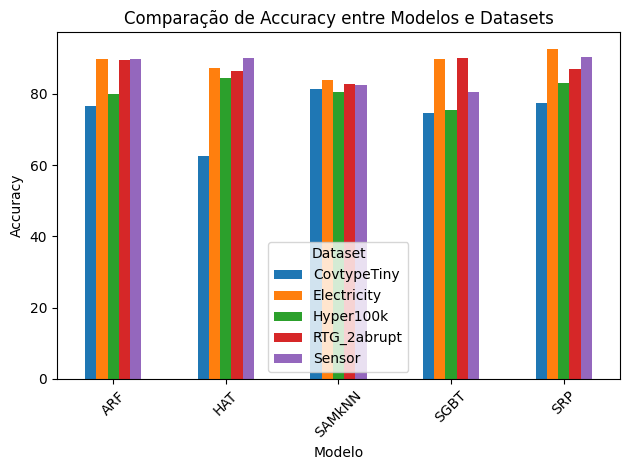

In [24]:
pivot_acc.plot(kind="bar")
plt.title("Comparação de Accuracy entre Modelos e Datasets")
plt.xlabel("Modelo")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

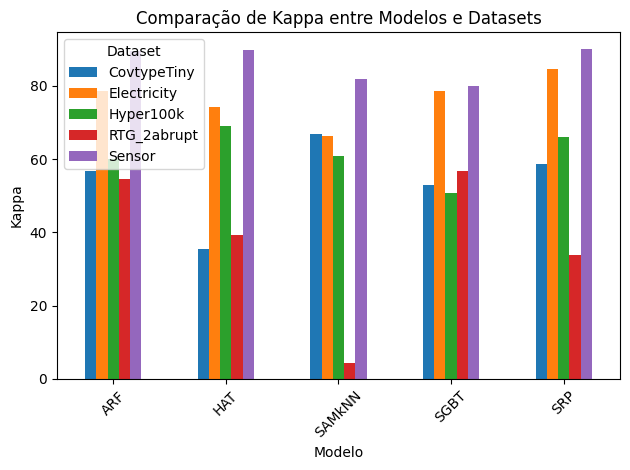

In [25]:
pivot_kappa.plot(kind="bar")
plt.title("Comparação de Kappa entre Modelos e Datasets")
plt.xlabel("Modelo")
plt.ylabel("Kappa")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

obs: nota-seque o modelo SAMkNN apresentou desempenho inferior em alguns datasets, especialmente em cenários com mudanças abruptas (como RTG_2abrupt). Como o SAMkNN é um método baseado em memória que depende fortemente da similaridade entre instâncias passadas e atuais, exemplos antigos tornam-se rapidamente obsoletos na presença de concept drift, principalmente abrupto, prejudicando a qualidade das previsões. Além disso, o modelo pode ser sensível ao desbalanceamento de classes, o que impacta negativamente métricas como o Kappa.

In [26]:
def plot_drift(dataset_class, model_name, model, max_instances=2000):

    stream = dataset_class()

    res = prequential_evaluation(
        stream=stream,
        learner=model,
        max_instances=max_instances,
        window_size=100
    )

    # pega desempenho ao longo do tempo
    windowed_acc = res["windowed"].accuracy()

    plt.figure()
    plt.plot(windowed_acc)

    plt.title(f"Drift - {model_name}")
    plt.xlabel("Instâncias")
    plt.ylabel("Accuracy (janela)")

    plt.show()

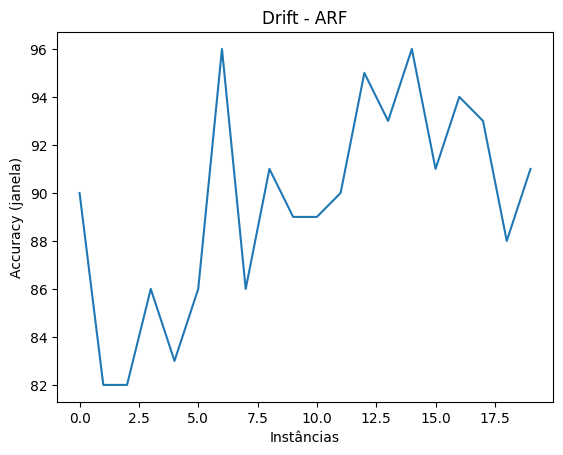

In [27]:
stream = RTG_2abrupt()
schema = stream.get_schema()

model = AdaptiveRandomForestClassifier(schema=schema)

plot_drift(RTG_2abrupt, "ARF", model)

In [28]:
def compare_models_drift(dataset_class, max_instances=5000):

    stream = dataset_class()
    schema = stream.get_schema()

    plt.figure()

    for name, model in get_models(schema).items():

        stream = dataset_class()

        res = prequential_evaluation(
            stream=stream,
            learner=model,
            max_instances=max_instances,
            window_size=100
        )

        acc = res["windowed"].accuracy()

        plt.plot(acc, label=name)

    plt.title("Desempenho ao longo do tempo (Drift)")
    plt.xlabel("Instâncias")
    plt.ylabel("Accuracy (janela)")
    plt.legend()

    plt.show()

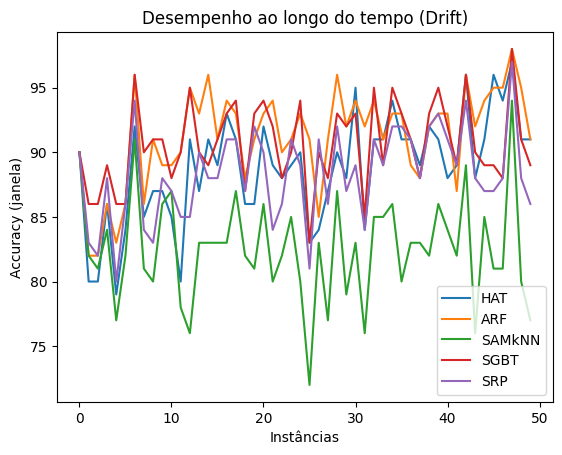

In [29]:
compare_models_drift(RTG_2abrupt)